<a href="https://colab.research.google.com/github/cjdevx-ai/Robotics-Technology-Assignments/blob/main/FetalinoClarenceJay_DataPreparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For Data manipulation
import numpy as np
import pandas as pd

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# For Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# For Feature selection
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("√ All libraries are imported successfully!")

√ All libraries are imported successfully!


In [2]:
# 2. Load and Explore the Dataset

# Create new variable dataset
dataset = pd.read_csv('heart_disease.csv')
print(dataset.to_string())

# To check the dataset dimension
print("\n" + "="*40)
print("Dataset Dimension:")
print("="*40)

dataset.shape # For the Number of Rows and Columns

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  target
0     67    0   4       152   188    0        2       89      0      5.5      1  0.0   7.0       1
1     57    1   1       163   275    0        1      104      1      0.5      1  3.0   7.0       1
2     43    0   3       194   279    0        2      148      1      4.5      1  3.0   6.0       0
3     71    0   1       126   281    0        2      195      0      1.2      1  2.0   6.0       0
4     36    1   2       146   495    0        1      187      0      5.3      1  0.0   3.0       1
5     49    1   2       115   174    0        0      122      0      5.1      2  3.0   7.0       0
6     67    1   4       114   462    0        0       97      1      3.4      1  2.0   NaN       1
7     47    0   2       163   209    0        2      105      0      4.4      2  0.0   3.0       0
8     51    1   2       163   486    0        0      176      0      1.9      1  1.0   6.0       0
9     39  

(303, 14)

Target Variable Distribution:
target
1    160
0    143
Name: count, dtype: int64

 No Disease (0): 143 (47.19%)
Disease (1):    160 (52.81%)


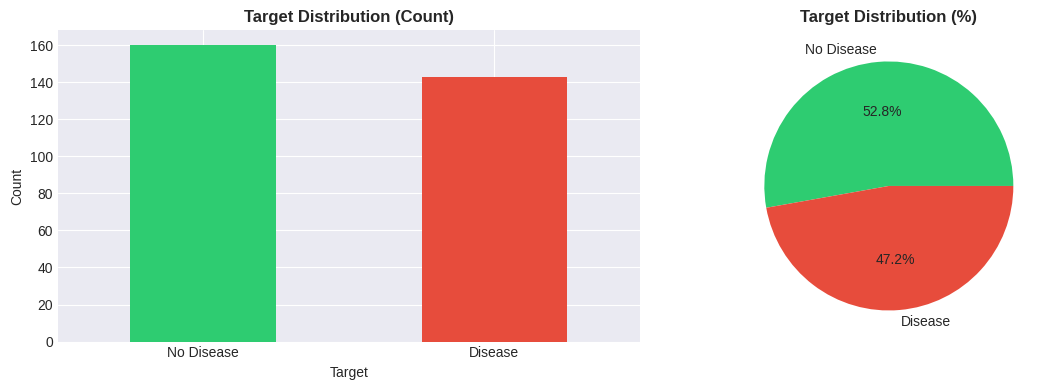

In [3]:
# Target variable distribution
print("="*80)
print("Target Variable Distribution:")
print("="*80)
print(dataset['target'].value_counts())
print(f"\n No Disease (0): {(dataset['target'] == 0).sum()} ({(dataset['target'] == 0).sum()/len(dataset)*100:.2f}%)")
print(f"Disease (1):    {(dataset['target'] == 1).sum()} ({(dataset['target'] == 1).sum()/len(dataset)*100:.2f}%)")

# To visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
dataset['target'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Target Distribution (Count)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Target')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

# Pie chart
dataset['target'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                     colors=['#2ecc71', '#e74c3c'], labels=['No Disease', 'Disease'])
ax[1].set_title('Target Distribution (%)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [4]:
dataset.isnull().sum().sort_values(ascending=False) #To See Columns for Missing Value

,0
ca,4
thal,2
cp,0
trestbps,0
age,0
sex,0
fbs,0
chol,0
restecg,0
thalach,0


In [5]:
dataset_clean = dataset.copy()

features_with_missing_values = ['ca', 'thal']

for col in features_with_missing_values:
    if col in dataset_clean.columns and dataset_clean[col].isnull().sum() > 0:
        median_value = dataset_clean[col].median()
        missing_count = dataset_clean[col].isnull().sum()
        dataset_clean[col].fillna(median_value, inplace=True)
        print(f"✓ {col}: Filled {missing_count} missing values with median = {median_value}")

print(f"\n✓ Total missing values after imputation: {dataset_clean.isnull().sum().sum()}")

✓ ca: Filled 4 missing values with median = 1.0
✓ thal: Filled 2 missing values with median = 6.0

✓ Total missing values after imputation: 0


In [6]:
dataset_clean = dataset.copy()

features_with_missing_values = ['ca', 'thal']

for col in features_with_missing_values:
    if col in dataset_clean.columns and dataset_clean[col].isnull().sum() > 0:
        mean_value = dataset_clean[col].mean()
        missing_count = dataset_clean[col].isnull().sum()
        dataset_clean[col].fillna(mean_value, inplace=True)
        print(f"✓ {col}: Filled {missing_count} missing values with mean = {mean_value}")

print(f"\n✓ Total missing values after imputation: {dataset_clean.isnull().sum().sum()}")

✓ ca: Filled 4 missing values with mean = 1.5016722408026757
✓ thal: Filled 2 missing values with mean = 5.225913621262459

✓ Total missing values after imputation: 0


In [7]:
# To create a copy for processing
dataset_clean = dataset.copy()

# For numerical features: Using Mean
features_with_missing_values = ['ca', 'thal']

for col in features_with_missing_values:
    if col in dataset_clean.columns and dataset_clean[col].isnull().sum() > 0:
        mean_value = dataset_clean[col].mean()
        missing_count = dataset_clean[col].isnull().sum()
        dataset_clean[col].fillna(mean_value, inplace=True)
        print(f"✓ {col}: Filled {missing_count} missing values with mean = {mean_value}")

print(f"\n✓ Total missing values after imputation: {dataset_clean.isnull().sum().sum()}")

✓ ca: Filled 4 missing values with mean = 1.5016722408026757
✓ thal: Filled 2 missing values with mean = 5.225913621262459

✓ Total missing values after imputation: 0


In [8]:
# Check for duplicates
duplicates = dataset_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"\nRemoving {duplicates} duplicate rows...")
    dataset_clean = dataset_clean.drop_duplicates()
    print(f"✓ Dataset shape after removing duplicates: {dataset_clean.shape}")
else:
    print("✓ No duplicate rows found!")


Number of duplicate rows: 0
✓ No duplicate rows found!


In [9]:
print(dataset_clean.to_string())

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope        ca      thal  target
0     67    0   4       152   188    0        2       89      0      5.5      1  0.000000  7.000000       1
1     57    1   1       163   275    0        1      104      1      0.5      1  3.000000  7.000000       1
2     43    0   3       194   279    0        2      148      1      4.5      1  3.000000  6.000000       0
3     71    0   1       126   281    0        2      195      0      1.2      1  2.000000  6.000000       0
4     36    1   2       146   495    0        1      187      0      5.3      1  0.000000  3.000000       1
5     49    1   2       115   174    0        0      122      0      5.1      2  3.000000  7.000000       0
6     67    1   4       114   462    0        0       97      1      3.4      1  2.000000  5.225914       1
7     47    0   2       163   209    0        2      105      0      4.4      2  0.000000  3.000000       0
8     51    1   2       163 

In [10]:
# Outlier detection using IQR method
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] # numeric data - prone to outliers

print("Outlier Detection using IQR Method:")
print("-" * 60)

outlier_summary = []

for col in numerical_cols:
    Q1 = dataset_clean[col].quantile(0.25)
    Q3 = dataset_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset_clean[(dataset_clean[col] < lower_bound) | (dataset_clean[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(dataset_clean)) * 100

    outlier_summary.append({
        'Feature': col,
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percent:.2f}%",
        'Lower Bound': f"{lower_bound:.2f}",
        'Upper Bound': f"{upper_bound:.2f}"
    })

outlier_dataset = pd.DataFrame(outlier_summary)
print(outlier_dataset.to_string(index=False))


Outlier Detection using IQR Method:
------------------------------------------------------------
 Feature  Outlier Count Outlier % Lower Bound Upper Bound
     age              0     0.00%        2.50      102.50
trestbps              0     0.00%       44.25      242.25
    chol              0     0.00%      -82.50      745.50
 thalach              0     0.00%       -2.00      274.00
 oldpeak              0     0.00%       -2.42        8.57


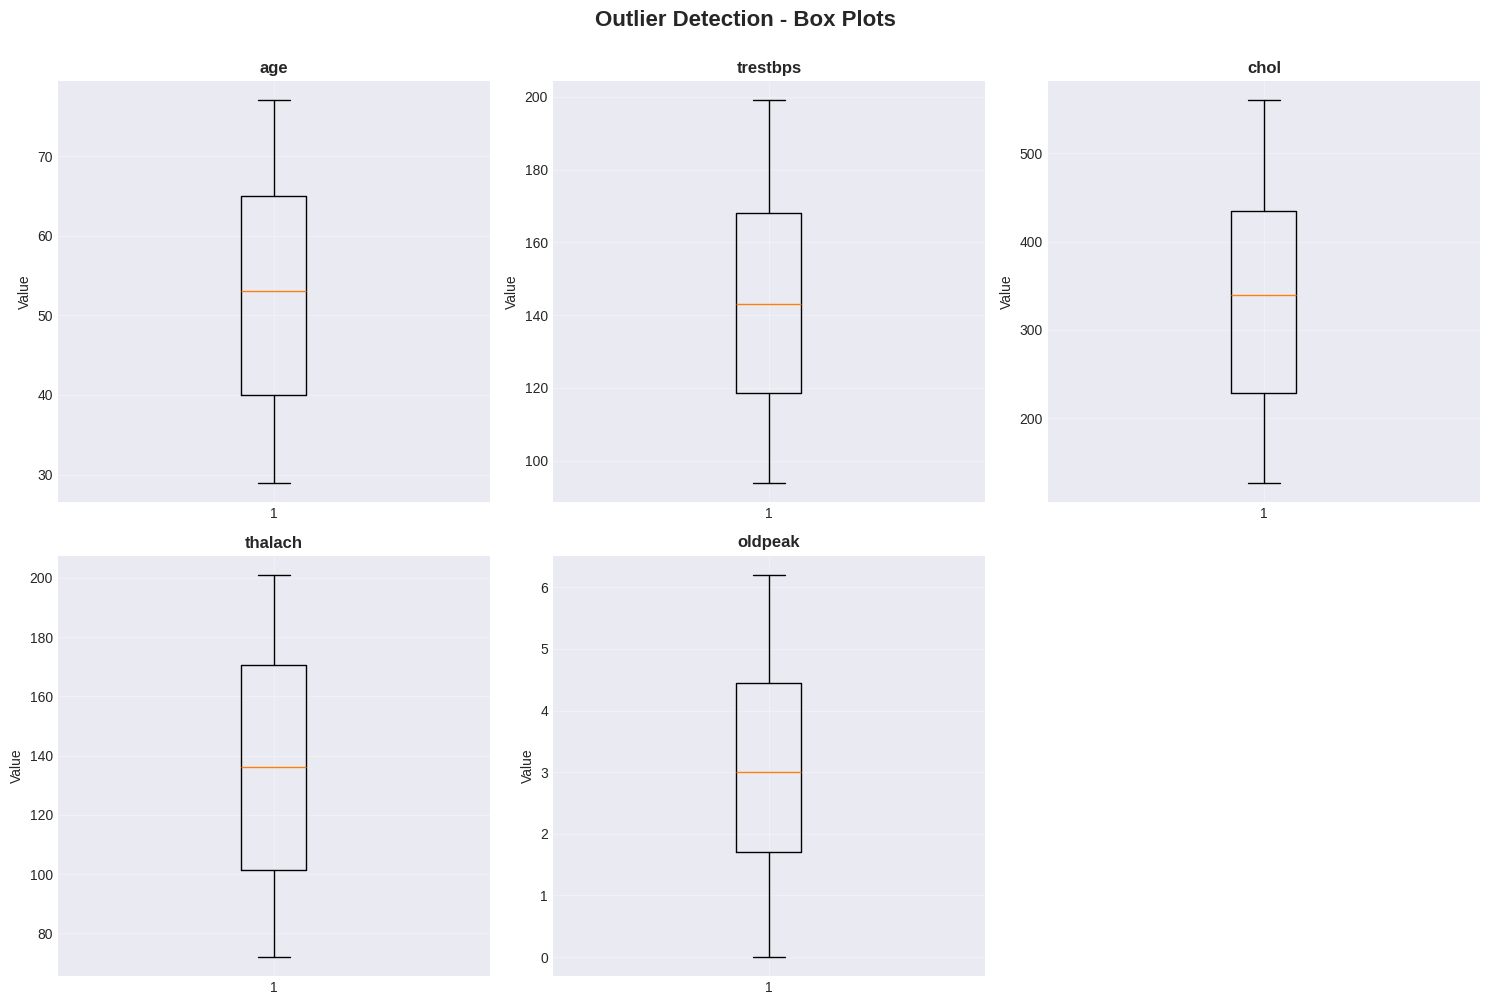


⚠ Note: Sometimes outliers are retained as they may represent valid extreme cases in medical data.


In [11]:
# To visualize outliers using box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(dataset_clean[col].dropna())
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

axes[-1].remove()

plt.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n⚠ Note: Sometimes outliers are retained as they may represent valid extreme cases in medical data.")


In [12]:
# To classify features by type
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'] #categorical type
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] #numerical type
target_feature = 'target'

print("="*100)
print("Features and Target:")
print("="*100)
print(f"\nCategorical Features ({len(categorical_features)}):")
for feat in categorical_features:
    unique_vals = dataset_clean[feat].nunique()
    print(f" • {feat:12s} - {unique_vals} unique values: {sorted(dataset_clean[feat].unique())}")

print(f"\nNumerical Features ({len(numerical_features)}):")
for feat in numerical_features:
    print(f" • {feat:12s} - Range: [{dataset_clean[feat].min():.2f}, {dataset_clean[feat].max():.2f}]")

print(f"\nTarget Feature:")
print(f" • {target_feature:12s} - Binary: {sorted(dataset_clean[target_feature].unique())}")


Features and Target:

Categorical Features (8):
 • sex          - 2 unique values: [np.int64(0), np.int64(1)]
 • cp           - 4 unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
 • fbs          - 2 unique values: [np.int64(0), np.int64(1)]
 • restecg      - 3 unique values: [np.int64(0), np.int64(1), np.int64(2)]
 • exang        - 2 unique values: [np.int64(0), np.int64(1)]
 • slope        - 3 unique values: [np.int64(1), np.int64(2), np.int64(3)]
 • ca           - 5 unique values: [np.float64(0.0), np.float64(1.0), np.float64(1.5016722408026757), np.float64(2.0), np.float64(3.0)]
 • thal         - 4 unique values: [np.float64(3.0), np.float64(5.225913621262459), np.float64(6.0), np.float64(7.0)]

Numerical Features (5):
 • age          - Range: [29.00, 77.00]
 • trestbps     - Range: [94.00, 199.00]
 • chol         - Range: [127.00, 560.00]
 • thalach      - Range: [72.00, 201.00]
 • oldpeak      - Range: [0.00, 6.20]

Target Feature:
 • target       - Binary: [np.

In [13]:
# To create copy for encoding
dataset_encoded = dataset_clean.copy()

print("="*100)
print("Encoding Strategy:")
print("="*100)
print("  1. Binary features (sex, fbs, exang): Already in binary format (0/1)")
print("  2. Ordinal features (cp, slope): Keep as is (natural ordering)")
print("  3. Nominal features (restecg, ca, thal): One-Hot Encoding")

# One-Hot Encoding for nominal features
nominal_features = ['restecg', 'ca', 'thal']
dataset_encoded = pd.get_dummies(dataset_encoded, columns=nominal_features, prefix=nominal_features, drop_first=True)

print(f"\n✓ Dataset shape after encoding: {dataset_encoded.shape}")
print(f"✓ New columns created: {dataset_encoded.shape[1] - dataset_clean.shape[1]}")
print("\nEncoded column names:")
print(list(dataset_encoded.columns))
print(dataset_encoded.to_string())


Encoding Strategy:
  1. Binary features (sex, fbs, exang): Already in binary format (0/1)
  2. Ordinal features (cp, slope): Keep as is (natural ordering)
  3. Nominal features (restecg, ca, thal): One-Hot Encoding

✓ Dataset shape after encoding: (303, 20)
✓ New columns created: 6

Encoded column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'target', 'restecg_1', 'restecg_2', 'ca_1.0', 'ca_1.5016722408026757', 'ca_2.0', 'ca_3.0', 'thal_5.225913621262459', 'thal_6.0', 'thal_7.0']
     age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  slope  target  restecg_1  restecg_2  ca_1.0  ca_1.5016722408026757  ca_2.0  ca_3.0  thal_5.225913621262459  thal_6.0  thal_7.0
0     67    0   4       152   188    0       89      0      5.5      1       1      False       True   False                  False   False   False                   False     False      True
1     57    1   1       163   275    0      104      1      0.5      1       1   

In [14]:
dataset_encoded


,age,sex,cp,trestbps,chol,fbs,thalach,exang,oldpeak,slope,target,restecg_1,restecg_2,ca_1.0,ca_1.5016722408026757,ca_2.0,ca_3.0,thal_5.225913621262459,thal_6.0,thal_7.0
0,67,0,4,152,188,0,89,0,5.5,1,1,False,True,False,False,False,False,False,False,True
1,57,1,1,163,275,0,104,1,0.5,1,1,True,False,False,False,False,True,False,False,True
2,43,0,3,194,279,0,148,1,4.5,1,0,False,True,False,False,False,True,False,True,False
3,71,0,1,126,281,0,195,0,1.2,1,0,False,True,False,False,True,False,False,True,False
4,36,1,2,146,495,0,187,0,5.3,1,1,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,66,1,2,163,407,0,80,0,1.8,1,1,False,False,False,False,False,True,False,False,False
299,68,0,4,181,211,0,161,0,6.0,1,1,False,True,False,False,False,True,False,False,True
300,48,1,2,126,375,0,72,0,2.4,3,1,False,True,True,False,False,False,False,False,False
301,63,1,3,142,516,0,188,0,2.4,1,1,False,True,False,True,False,False,False,False,False


In [15]:
dataset_encoded.describe()


,age,sex,cp,trestbps,chol,fbs,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.953795,0.702970,2.372937,143.564356,335.650165,0.178218,135.448845,0.326733,3.037954,2.026403,0.528053
std,14.371992,0.457706,1.077860,30.442569,123.330935,0.383329,39.379330,0.469794,1.768370,0.837429,0.500038
min,29.000000,0.000000,1.000000,94.000000,127.000000,0.000000,72.000000,0.000000,0.000000,1.000000,0.000000
25%,40.000000,0.000000,1.000000,118.500000,228.000000,0.000000,101.500000,0.000000,1.700000,1.000000,0.000000
50%,53.000000,1.000000,2.000000,143.000000,340.000000,0.000000,136.000000,0.000000,3.000000,2.000000,1.000000
75%,65.000000,1.000000,3.000000,168.000000,435.000000,0.000000,170.500000,1.000000,4.450000,3.000000,1.000000
max,77.000000,1.000000,4.000000,199.000000,560.000000,1.000000,201.000000,1.000000,6.200000,3.000000,1.000000


In [16]:
# To separate features and target
X = dataset_encoded.drop('target', axis=1) #independent variable
y = dataset_encoded['target']              #dependent variable

print("Feature-Target Split:")
print(f" Features (X): {X.shape}")
print(f" Target (y): {y.shape}")

# Identify numerical columns in encoded dataset
numerical_cols_encoded = [col for col in X.columns if col in numerical_features]
print(f"\nNumerical features for scaling: {numerical_cols_encoded}")


Feature-Target Split:
 Features (X): (303, 19)
 Target (y): (303,)

Numerical features for scaling: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [17]:
# To compare different scaling methods
scaling_comparison = pd.DataFrame()
scaling_comparison['Original'] = X[numerical_features].iloc[0]

# 1. StandardScaler
scaler_standard = StandardScaler()
X_standard = X.copy()
X_standard[numerical_cols_encoded] = scaler_standard.fit_transform(X[numerical_cols_encoded])
scaling_comparison['StandardScaler'] = X_standard[numerical_features].iloc[0]

# 2. MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax = X.copy()
X_minmax[numerical_cols_encoded] = scaler_minmax.fit_transform(X[numerical_cols_encoded])
scaling_comparison['MinMaxScaler'] = X_minmax[numerical_features].iloc[0]

# 3. RobustScaler
scaler_robust = RobustScaler()
X_robust = X.copy()
X_robust[numerical_cols_encoded] = scaler_robust.fit_transform(X[numerical_cols_encoded])
scaling_comparison['RobustScaler'] = X_robust[numerical_features].iloc[0]

print("Scaling Methods Comparison (First sample):")
print("="*80)
print(scaling_comparison.T)

# Use StandardScaler for subsequent analysis
X_scaled = X_standard
print("\n✓ StandardScaler selected for further analysis")


Scaling Methods Comparison (First sample):
                      age    trestbps        chol    thalach   oldpeak
Original        67.000000  152.000000  188.000000  89.000000  5.500000
StandardScaler   0.978949    0.277559   -1.199167  -1.181475  1.394572
MinMaxScaler     0.791667    0.552381    0.140878   0.131783  0.887097
RobustScaler     0.560000    0.181818   -0.734300  -0.681159  0.909091

✓ StandardScaler selected for further analysis


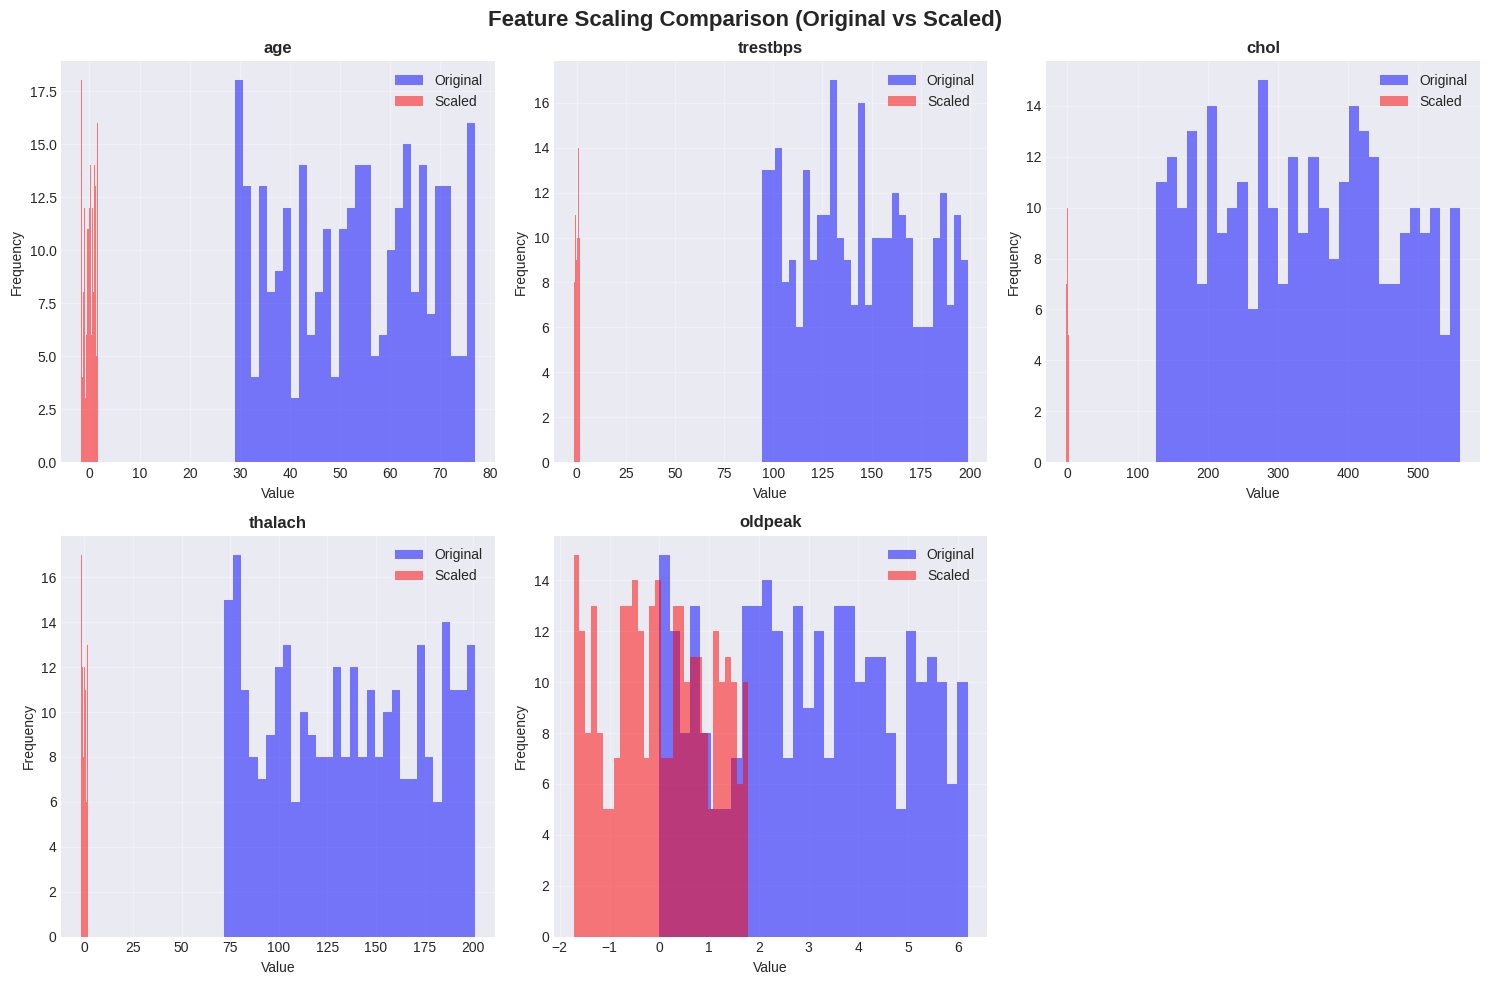

In [18]:
# To visualize the scaling effect
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(X[col], bins=30, alpha=0.5, label='Original', color='blue')
    axes[idx].hist(X_scaled[col], bins=30, alpha=0.5, label='Scaled', color='red')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].remove()

plt.suptitle('Feature Scaling Comparison (Original vs Scaled)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [19]:
# To split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset Split (80% Train, 20% Test):")
print("-" * 60)
print(f" Training set:  X_train {X_train.shape}, y_train {y_train.shape}")
print(f" Test set:      X_test {X_test.shape}, y_test {y_test.shape}")

print("\nClass Distribution in Splits:")
train_dist = y_train.value_counts()
test_dist = y_test.value_counts()

print(f"\nTraining Set:")
print(f" No Disease (0): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f" Disease (1):    {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")

print(f"\nTest Set:")
print(f" No Disease (0): {test_dist[0]} ({test_dist[0]/len(y_test)*100:.2f}%)")
print(f" Disease (1):    {test_dist[1]} ({test_dist[1]/len(y_test)*100:.2f}%)")

print("\n✓ Stratified split ensures balanced class distribution bakla")


Dataset Split (80% Train, 20% Test):
------------------------------------------------------------
 Training set:  X_train (242, 19), y_train (242,)
 Test set:      X_test (61, 19), y_test (61,)

Class Distribution in Splits:

Training Set:
 No Disease (0): 114 (47.11%)
 Disease (1):    128 (52.89%)

Test Set:
 No Disease (0): 29 (47.54%)
 Disease (1):    32 (52.46%)

✓ Stratified split ensures balanced class distribution bakla


Feature Correlation with Target:
target                    1.000000
age                       0.313957
oldpeak                   0.277585
chol                      0.258906
sex                       0.224610
cp                        0.210912
trestbps                  0.171997
exang                     0.151143
restecg_2                 0.103831
thalach                   0.062250
ca_2.0                    0.060808
ca_1.0                    0.014220
slope                     0.006133
thal_5.225913621262459   -0.004581
ca_1.5016722408026757    -0.006500
thal_7.0                 -0.019392
ca_3.0                   -0.027104
thal_6.0                 -0.064703
restecg_1                -0.067559
fbs                      -0.077994
Name: target, dtype: float64


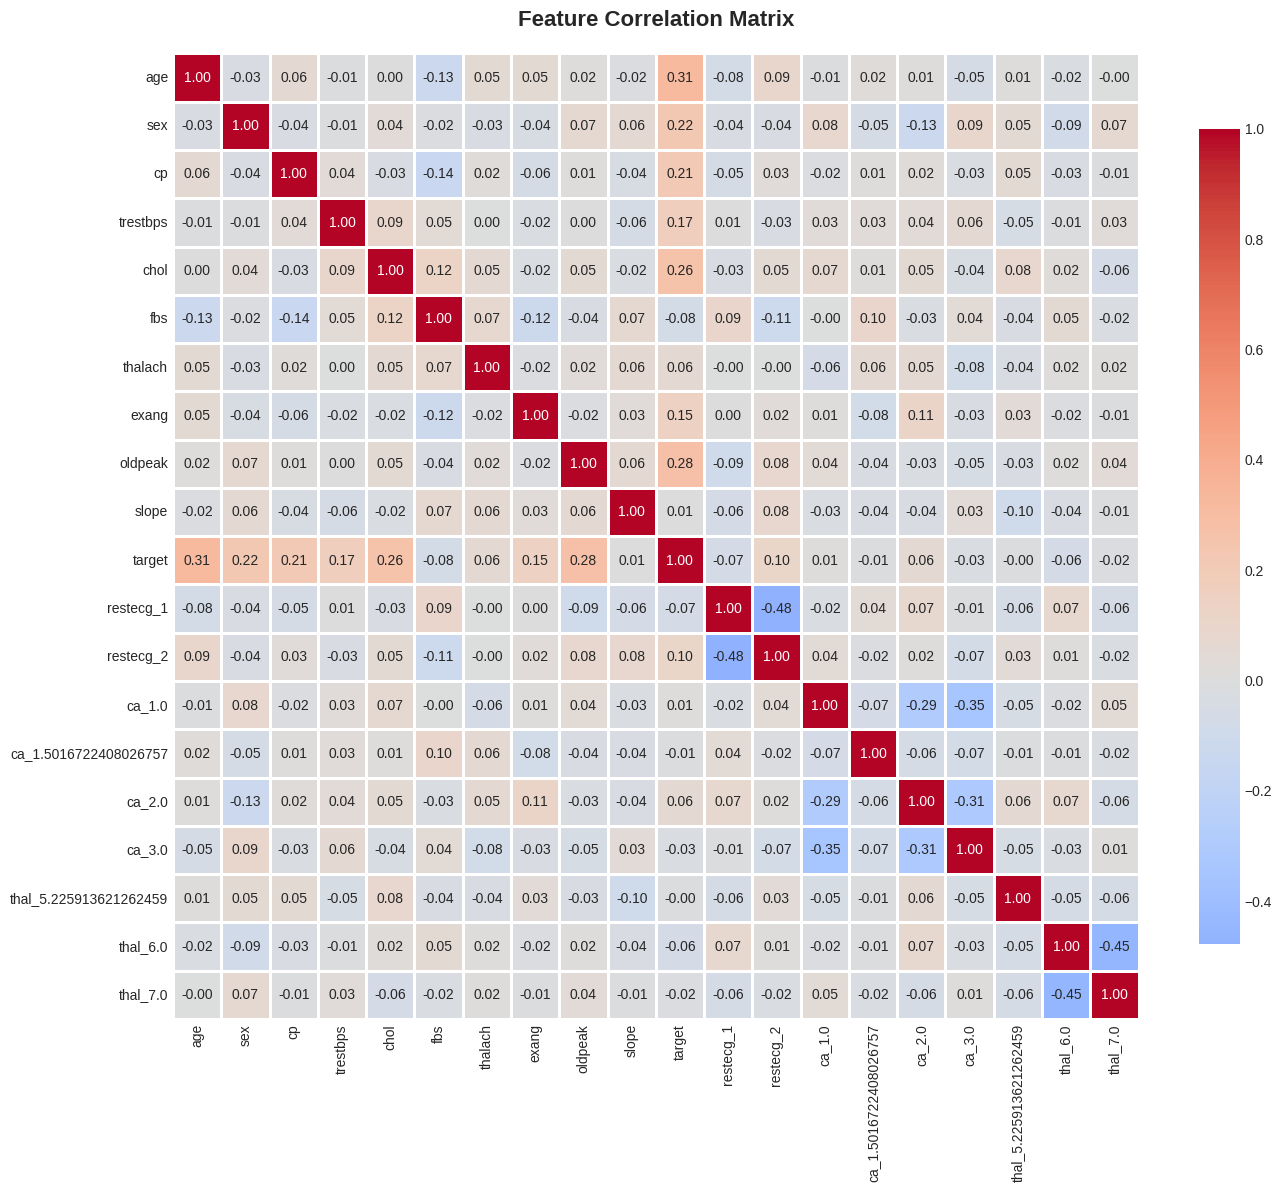

In [20]:
# To compute the correlation matrix
correlation_matrix = dataset_encoded.corr()

# Correlation with target
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
print("Feature Correlation with Target:")
print("="*40)
print(target_correlation)

# To visualize correlation matrix of the X (independent variables)
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [21]:
# To apply SelectKBest with f_classif
k = 10  # to select top 10 features
selector = SelectKBest(score_func=f_classif, k=k)
X_train_kbest = selector.fit_transform(X_train, y_train)

# Get feature scores
feature_scores = pd.DataFrame({'Feature': X_train.columns, 'Score': selector.scores_}).sort_values('Score', ascending=False)

print(f"Top {k} Features by F-statistic Score:")
print("="*80)
print(feature_scores.head(k))

selected_features_kbest = X_train.columns[selector.get_support()].tolist()
print(f"\n✓ Selected Features: {selected_features_kbest}")

Top 10 Features by F-statistic Score:
                   Feature      Score
0                      age  28.875357
4                     chol  16.743484
2                       cp  16.175006
8                  oldpeak  14.176415
3                 trestbps   9.458085
1                      sex   9.174362
7                    exang   3.020628
11               restecg_2   2.597672
14                  ca_2.0   1.356828
16  thal_5.225913621262459   0.890219

✓ Selected Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'exang', 'oldpeak', 'restecg_2', 'ca_2.0', 'thal_5.225913621262459']


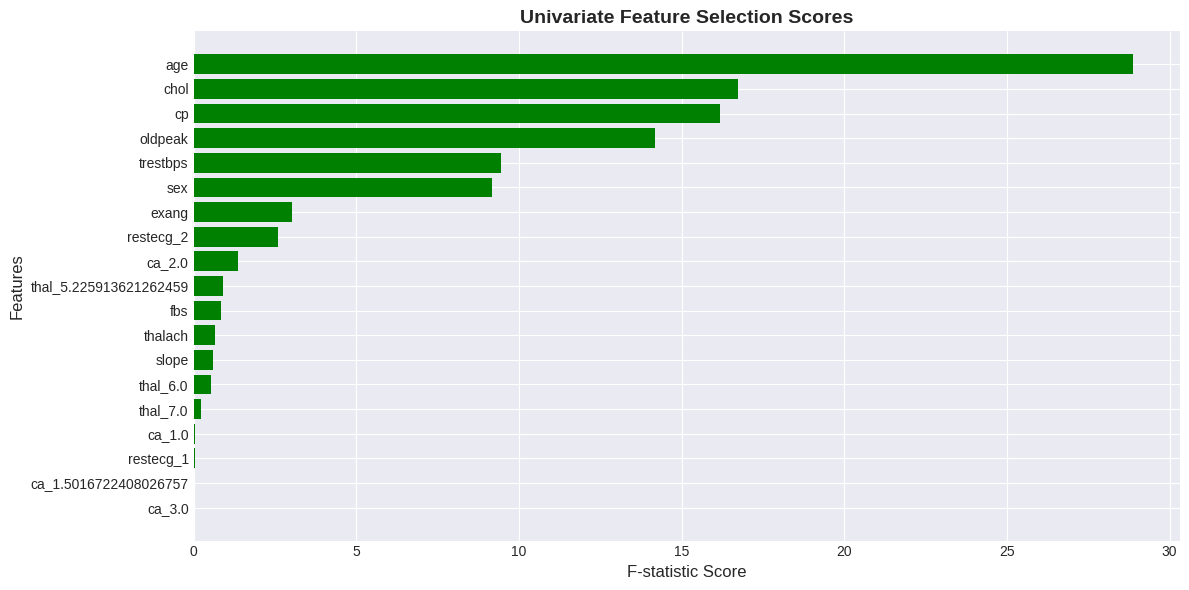

In [22]:
# To visualize feature scores
plt.figure(figsize=(12, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='green')
plt.xlabel('F-statistic Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Univariate Feature Selection Scores', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# n_estimators=100 means 'build 100 decision trees' in the Random Forest
# n_jobs=-1 - using all CPUs

# Apply RFE
n_features_rfe = 10
rfe = RFE(estimator=rf_model, n_features_to_select=n_features_rfe)
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Get selected features
rfe_ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': rfe.ranking_, 'Selected': rfe.support_}).sort_values('Ranking')

print("RFE Feature Ranking:")
print("="*50)
print(rfe_ranking)

selected_features_rfe = X_train.columns[rfe.support_].tolist()
print(f"\n✓ Selected Features (RFE): {selected_features_rfe}")

RFE Feature Ranking:
                   Feature  Ranking  Selected
0                      age        1      True
1                      sex        1      True
2                       cp        1      True
3                 trestbps        1      True
4                     chol        1      True
6                  thalach        1      True
7                    exang        1      True
8                  oldpeak        1      True
15                  ca_3.0        1      True
9                    slope        1      True
11               restecg_2        2     False
18                thal_7.0        3     False
17                thal_6.0        4     False
12                  ca_1.0        5     False
10               restecg_1        6     False
5                      fbs        7     False
14                  ca_2.0        8     False
13   ca_1.5016722408026757        9     False
16  thal_5.225913621262459       10     False

✓ Selected Features (RFE): ['age', 'sex', 'cp', 'trestbps'

In [24]:
# To train Random Forest to get feature importances
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train, y_train)

# Get feature importances
# Importance scores sum to 1.0 (100%)
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_importance.feature_importances_}).sort_values('Importance', ascending=False)

print("Feature Importance Scores:")
print("="*80)
print(feature_importance)

# Select features using SelectFromModel
sfm = SelectFromModel(rf_importance, threshold='median')
sfm.fit(X_train, y_train)
selected_features_importance = X_train.columns[sfm.get_support()].tolist()

print(f"\n✓ Selected Features (Importance > median): {selected_features_importance}")

Feature Importance Scores:
                   Feature  Importance
0                      age    0.211166
8                  oldpeak    0.162695
4                     chol    0.148377
3                 trestbps    0.116414
6                  thalach    0.087108
2                       cp    0.068024
9                    slope    0.034231
1                      sex    0.031533
18                thal_7.0    0.019761
7                    exang    0.019611
11               restecg_2    0.017018
17                thal_6.0    0.015153
12                  ca_1.0    0.014818
15                  ca_3.0    0.014744
5                      fbs    0.014583
10               restecg_1    0.012624
14                  ca_2.0    0.011891
13   ca_1.5016722408026757    0.000218
16  thal_5.225913621262459    0.000028

✓ Selected Features (Importance > median): ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'thal_7.0']


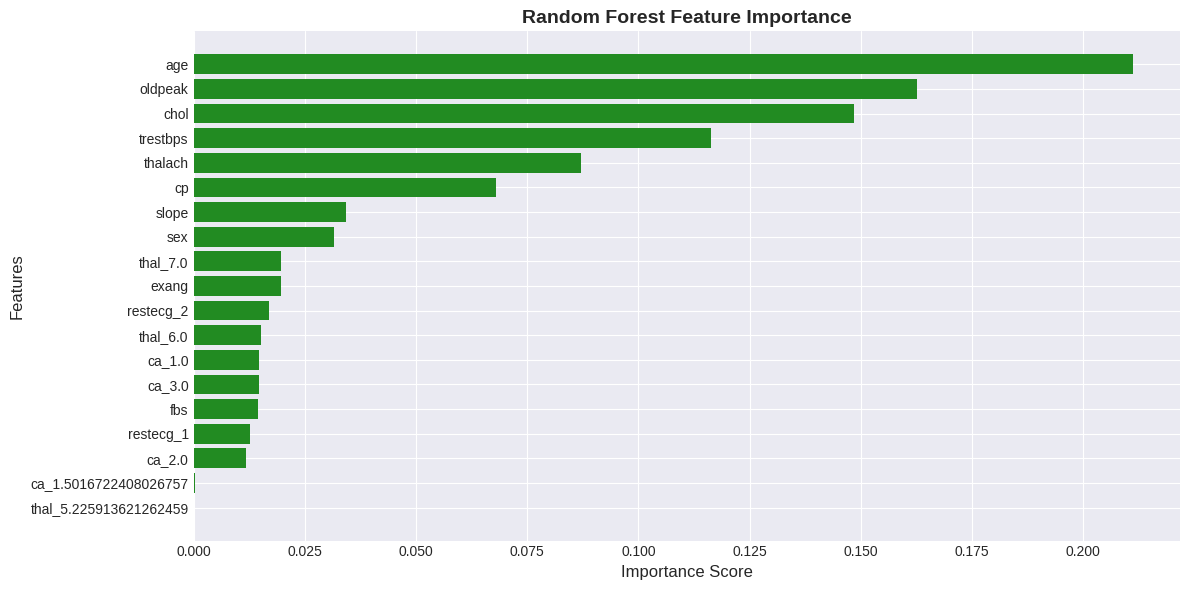

In [25]:
# To visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='forestgreen')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# To apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("PCA Results:")
print("="*80)
print(f"  Total features: {X_train.shape[1]}")
print(f"  Components for 95% variance: {n_components_95}")
print(f"\nExplained Variance by Component:")

variance_df = pd.DataFrame({
    'Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Variance Explained': pca.explained_variance_ratio_,
    'Cumulative Variance': cumulative_variance
})

print(variance_df.head(10))

PCA Results:
  Total features: 19
  Components for 95% variance: 14

Explained Variance by Component:
   Component  Variance Explained  Cumulative Variance
0          1            0.144657             0.144657
1          2            0.126338             0.270996
2          3            0.113904             0.384900
3          4            0.111255             0.496155
4          5            0.107019             0.603174
5          6            0.097188             0.700362
6          7            0.076356             0.776717
7          8            0.039803             0.816521
8          9            0.034001             0.850521
9         10            0.029430             0.879951


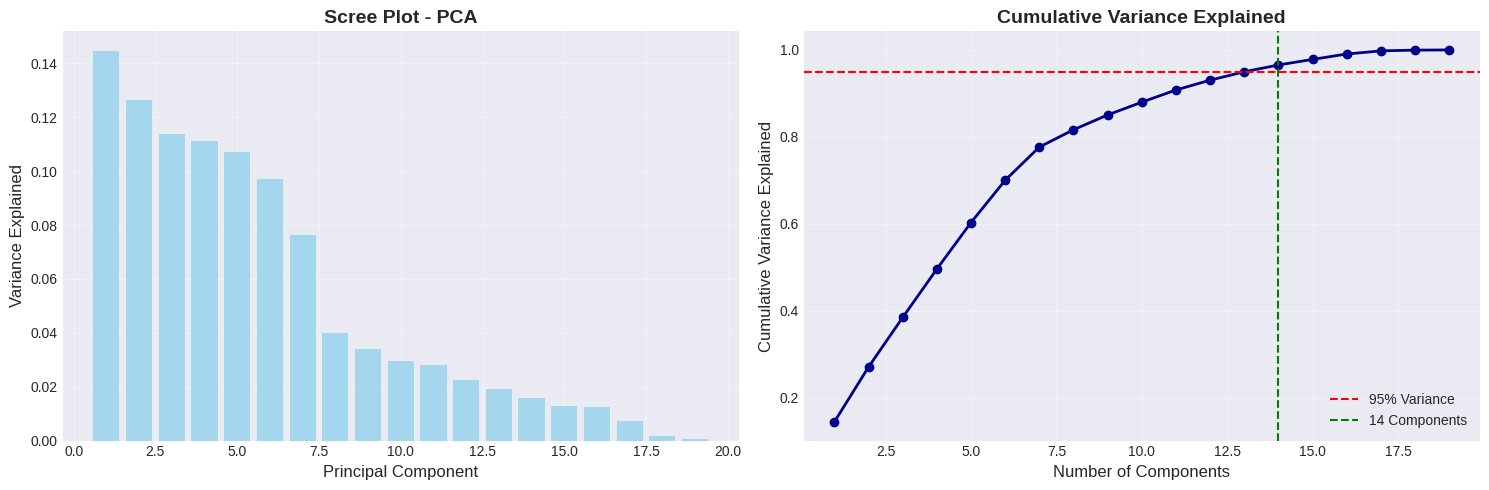


✓ PCA reduced features from 19 to 14


In [27]:
# To visualize PCA variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_, color='skyblue', alpha=0.7)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained', fontsize=12)
ax1.set_title('Scree Plot - PCA', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cumulative variance plot
ax2.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance, marker='o', color='darkblue', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
ax2.axvline(x=n_components_95, color='green', linestyle='--',
            label=f'{n_components_95} Components')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ PCA reduced features from {X_train.shape[1]} to {n_components_95}")

In [28]:
# Feature Selection Comparison
common_features = set(selected_features_kbest) & set(selected_features_rfe) & set(selected_features_importance)

comparison_data = {
    'Method': [
        'Univariate (SelectKBest)',
        'RFE (Recursive Feature Elimination)',
        'Tree-based Importance',
        'PCA (95% variance)'
    ],
    'Number of Features': [
        len(selected_features_kbest),
        len(selected_features_rfe),
        len(selected_features_importance),
        n_components_95
    ],
    'Selected Features': [
        ', '.join(selected_features_kbest[:5]) + '...',
        ', '.join(selected_features_rfe[:5]) + '...',
        ', '.join(selected_features_importance[:5]) + '...',
        f'PC1-PC{n_components_95}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("Feature Selection Methods Summary:")
print("="*80)
print(comparison_df)

print(f"\n✓ Common features selected by all 3 methods: {sorted(list(common_features))}")
print(f"  Total common features: {len(common_features)}")

Feature Selection Methods Summary:
                                Method  Number of Features  \
0             Univariate (SelectKBest)                  10   
1  RFE (Recursive Feature Elimination)                  10   
2                Tree-based Importance                  10   
3                   PCA (95% variance)                  14   

                 Selected Features  
0  age, sex, cp, trestbps, chol...  
1  age, sex, cp, trestbps, chol...  
2  age, sex, cp, trestbps, chol...  
3                         PC1-PC14  

✓ Common features selected by all 3 methods: ['age', 'chol', 'cp', 'exang', 'oldpeak', 'sex', 'trestbps']
  Total common features: 7


In [29]:
# Export processed datasets
dataset_clean.to_csv('heart_disease_cleaned.csv', index=False)
dataset_encoded.to_csv('heart_disease_encoded.csv', index=False)

# Save train-test splits
np.save('X_train.npy', X_train.values)
np.save('X_test.npy', X_test.values)
np.save('y_train.npy', y_train.values)
np.save('y_test.npy', y_test.values)

print("√ Processed datasets exported successfully!")
print("\nGenerated files:")
print("  • heart_disease_cleaned.csv")
print("  • heart_disease_encoded.csv")
print("  • X_train.npy, X_test.npy")
print("  • y_train.npy, y_test.npy")

√ Processed datasets exported successfully!

Generated files:
  • heart_disease_cleaned.csv
  • heart_disease_encoded.csv
  • X_train.npy, X_test.npy
  • y_train.npy, y_test.npy


#**Prepared by:**
***FETALINO, CLARENCE JAY M. | BS ECE 4-4***